# Maldroid Classifier based on API Sequences

## Explore Data

In [154]:
# !pip3 install lightning --quiet

In [1]:
# libraries
import numpy as np
import pandas as pd
import json 
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

import pytorch_lightning as L
import torch.nn.functional as F
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from torch.nn.utils.rnn import pad_sequence

import warnings
warnings.filterwarnings('ignore')

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# read json data
with open("../datasets/Sequence/train-sequence.json", "r") as f:
    train_data = json.load(f)

with open("../datasets/Sequence/test-sequence.json", "r") as f:
    test_data = json.load(f)

# create dataframes
df_train = pd.DataFrame(train_data)
df_test = pd.DataFrame(test_data)

In [3]:
# explore data
df_train.head()

,GMLnames,Label,Class
0,2108820187ab171c48e01e13df69a0790491995d72dcc5...,reset setLength length length stopTransaction ...,sms
1,c612a7e7397d081d9f0dae615b1df8d88a08c0713879c2...,handleMessage setText run sendMessage obtainMe...,sms
2,360e3286184ddd26fd77112ac52006ede82a883b94b5db...,getNumber toString onCreate setContentView sta...,sms
3,ab4a071d06ff8fc999133858b30039c6ae1751de54b5bd...,onReceive onStart findViewById onCreate onCrea...,adware
4,7196812142d7b61cb95cf3ad8a77928f,b toString append a close a hasNext iterator v...,riskware


In [4]:
df_train.iloc[1]['Label']

'handleMessage setText run sendMessage obtainMessage init findViewById run onClick onClick onStart getSystemService currentTimeMillis onReceive startService onCreate init startActivity getSystemService parse length getPackageName setContentView toString a toString append init append a startActivity onCreate init findViewById setContentView onCreate setContentView onOptionsItemSelected addFlags onCreateOptionsMenu add getString onCreate setProgress startActivity setContentView setOnClickListener findViewById onCreate init init getString a substring printStackTrace parseInt equals b init close a parse'

In [5]:
df_test.head()

,GMLnames,Label,Class
0,9bdbc17f7ce3767f03fc10b901b3a823,onCreate startOauthAuthorization startActivity...,riskware
1,46fcfd232e17e649acd2997142cef963b9e7fa955e1d35...,run run run d c onCreate licButtonClick1 endBu...,sms
2,37a060eb3cce65ddbf4eac4cff025baf,convertToString bindView setViewImage getStrin...,riskware
3,42bfb5a49f794de3b746c992eceb67cf35e8e5ec60140f...,getPref3 onReceive onCreate setContentView ini...,sms
4,c8280b8acebcf7441317414c6a6acfb3,clinit printStackTrace next next dumpStack ins...,riskware


Count the number of different api calls on the label. This label is the written sequence of api calls, por exampoe, "onCreate startOauthAuthorization ..." indicates that there is a sequence of api calls that starts with onCreate, then startOauthAuthorization, and so on. We want to count how many different api calls are there in the dataset.

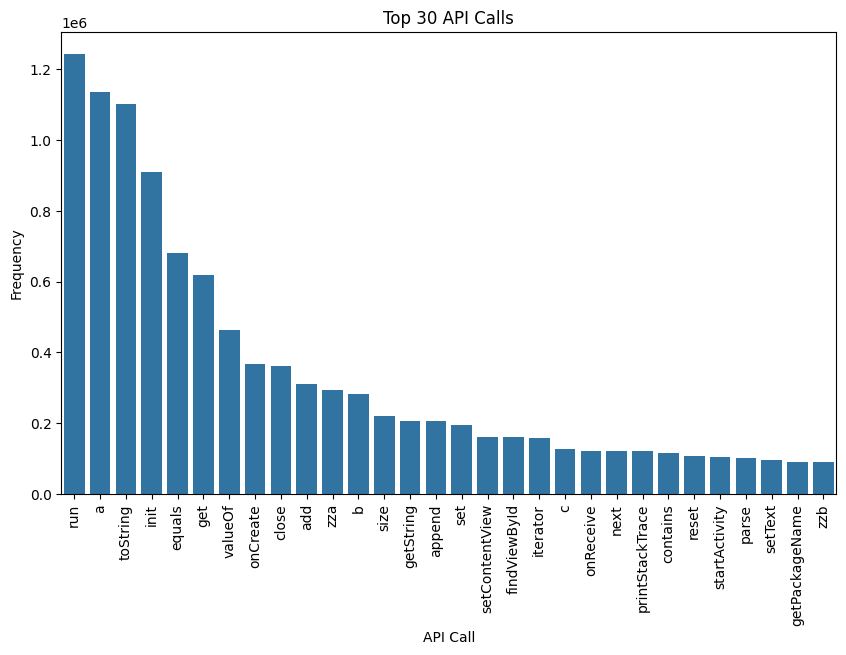

There are 209877 different API calls in the dataset.


In [6]:
# join all the labels in a single string
all_labels = " ".join(df_train['Label'].tolist())

# split the string into a list of api calls
api_calls = all_labels.split()

# count the number of different api calls and their frequency
api_calls_count = pd.Series(api_calls).value_counts()

# plot the top 30 api calls
plt.figure(figsize=(10,6))
sns.barplot(x=api_calls_count[:30].index, y=api_calls_count[:30].values)
plt.xticks(rotation=90)
plt.title("Top 30 API Calls")
plt.xlabel("API Call")
plt.ylabel("Frequency")
plt.show()

# print how many different api calls are there in the dataset
print(f"There are {len(api_calls_count)} different API calls in the dataset.")

Count the api calls most frequently used on each malware type (Class). This will give us an idea of which api calls are more relevant for each malware type, and we can use this information to select the most relevant features for our model.

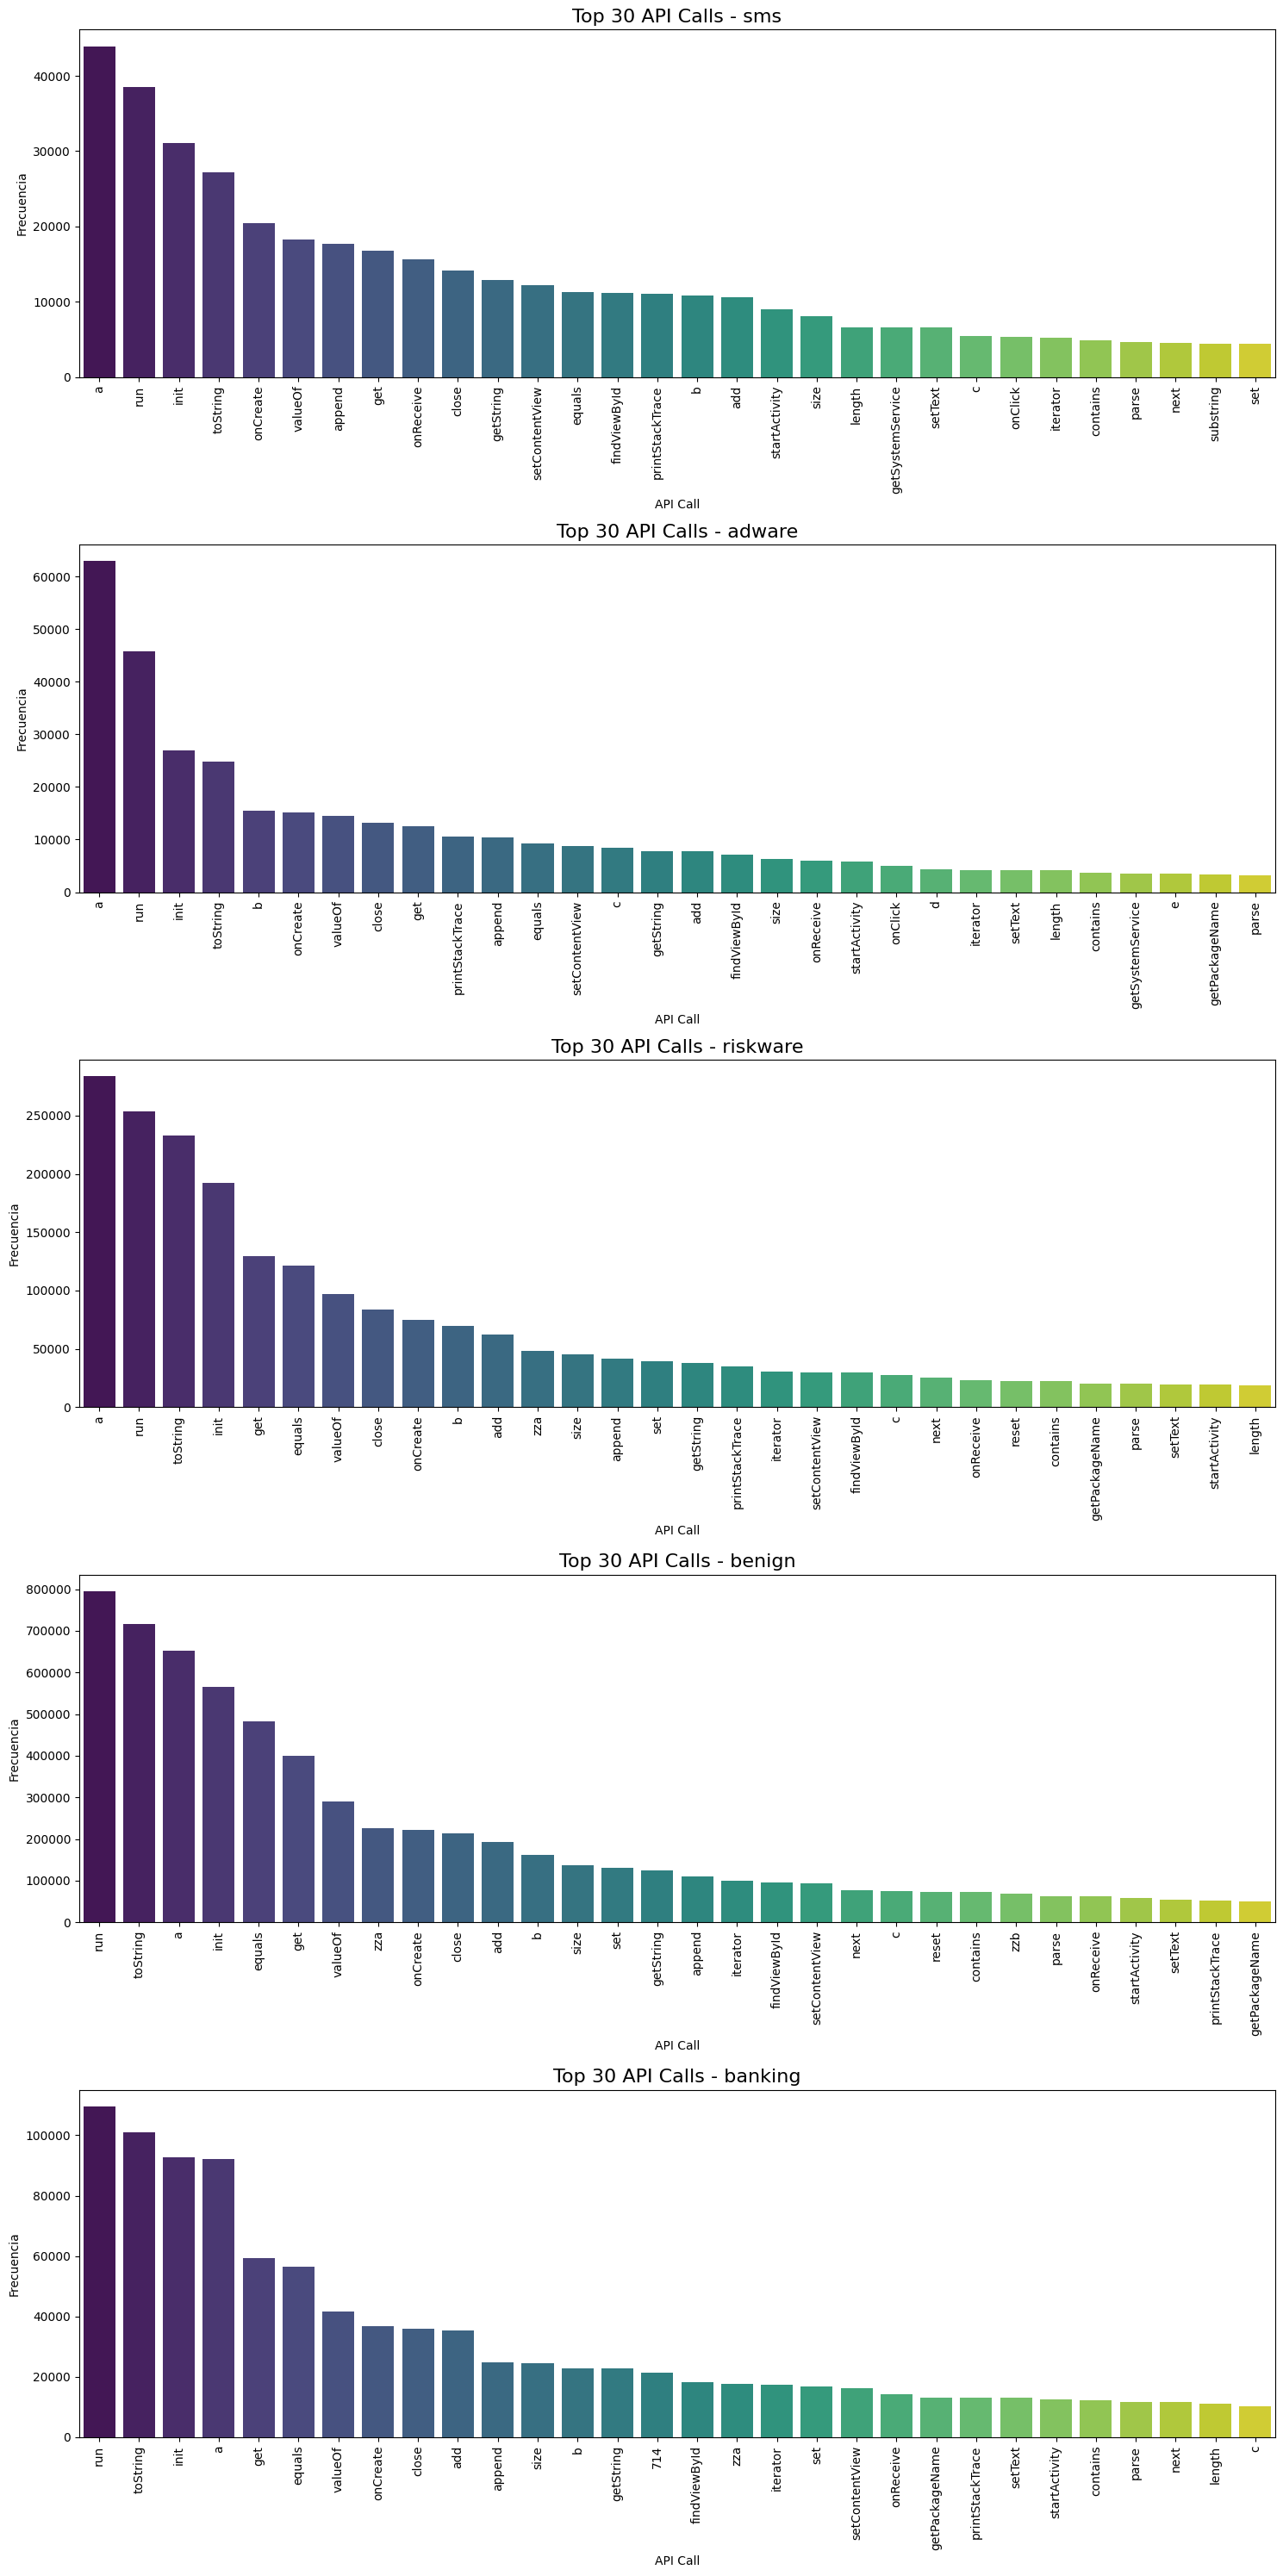

In [7]:
df_exploded = df_train.assign(Label=df_train['Label'].str.split()).explode('Label')

classes = df_train['Class'].unique()
n_classes = len(classes)

fig, axes = plt.subplots(nrows=n_classes, ncols=1, figsize=(15, 6 * n_classes))

if n_classes == 1:
    axes = [axes]

for i, malware_type in enumerate(classes):
    class_data = df_exploded[df_exploded['Class'] == malware_type]
    top_30_class = class_data['Label'].value_counts().nlargest(30)
    
    sns.barplot(
        x=top_30_class.index, 
        y=top_30_class.values, 
        ax=axes[i], 
        palette="viridis"
    )
    
    axes[i].set_title(f'Top 30 API Calls - {malware_type}', fontsize=16)
    axes[i].set_xticklabels(top_30_class.index, rotation=90)
    axes[i].set_ylabel('Frecuencia')
    axes[i].set_xlabel('API Call')

plt.tight_layout()
plt.show()

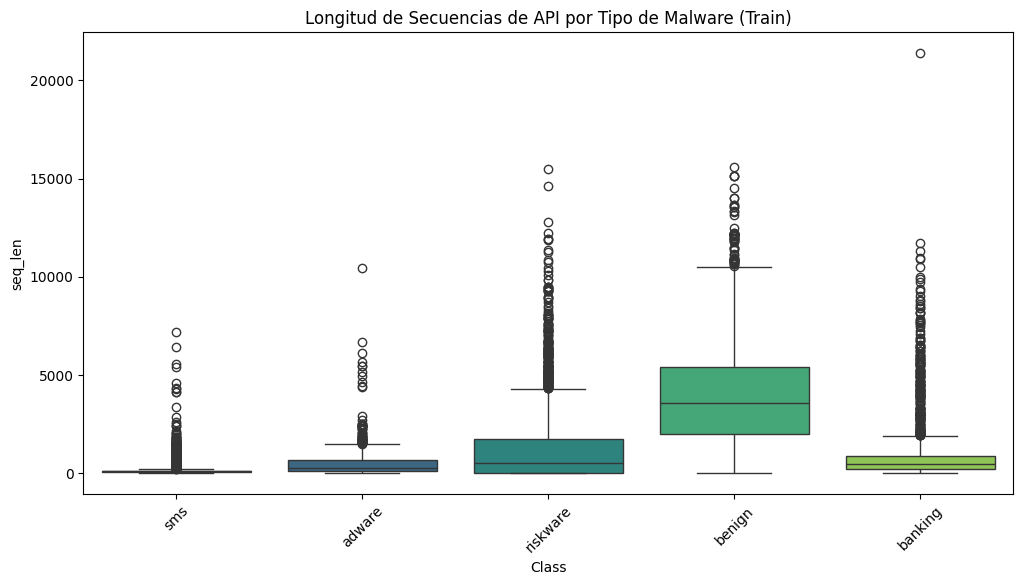

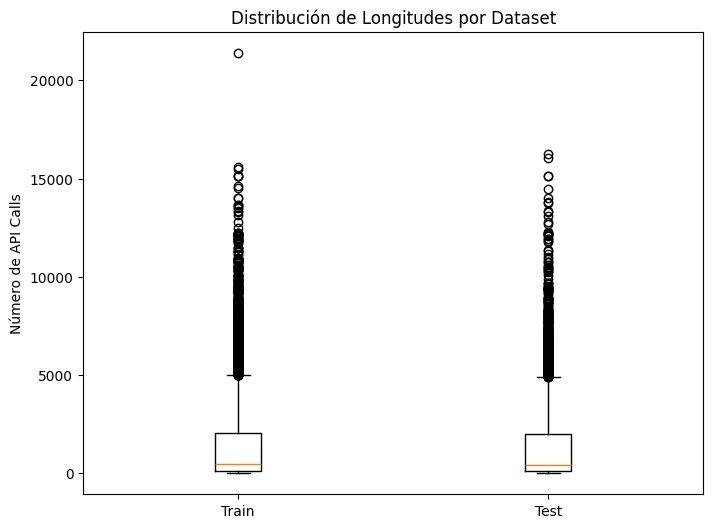

In [14]:
# distribucion de longitud de las secuencias (en todo el dataset)
# graficar boxplots por conjunto de datos (train y test)

df_train['seq_len'] = df_train['Label'].apply(lambda x: len(str(x).split()))
df_test['seq_len'] = df_test['Label'].apply(lambda x: len(str(x).split()))

# 1. Boxplot por Clase (Solo en Train para ver comportamiento del Malware)
plt.figure(figsize=(12, 6))
sns.boxplot(x='Class', y='seq_len', data=df_train, palette="viridis")
plt.title("Longitud de Secuencias de API por Tipo de Malware (Train)")
plt.xticks(rotation=45)
plt.show()

# 2. Comparación entre Conjuntos (para asegurar que la partición fue equitativa)
plt.figure(figsize=(8, 6))
data_to_plot = [df_train['seq_len'], df_test['seq_len']]
plt.boxplot(data_to_plot, labels=['Train', 'Test'])
plt.title("Distribución de Longitudes por Dataset")
plt.ylabel("Número de API Calls")
plt.show()

Ideas:
- Use CountVectorizer to tokenize the api calls as string and create a sparse matrix of token counts. It could make sense since the frecuency of api calls is relevant for the classification task. We can also use TfidfVectorizer.
- Train an embedding layer to learn a dense representation of the api calls.
- Use a RNN or LSTM model to capture the sequential nature of the api calls. This could be useful since the order of the api calls is relevant for the classification task. 

## Data Preprocessing
1. Split the training set into training and validation.
2. Tokenize the api calls using CountVectorizer or TfidfVectorizer.
3. Train a model using the training data and evaluate it on the testing data.

In [8]:
# separar un 10% del conjunto de entrenamiento para validación
df_train_new, df_val = train_test_split(
    df_train, 
    test_size=0.10, 
    random_state=26, 
    stratify=df_train['Class']
)

# tamaños
print(f"Train set: {len(df_train_new)} samples")
print(f"Validation set: {len(df_val)} samples")
print(f"Test set: {len(df_test)} samples")

# encoding de las etiquetas
le = LabelEncoder()
y_train_num = le.fit_transform(df_train_new['Class'])
y_val_num = le.transform(df_val['Class'])
y_test_num = le.transform(df_test['Class'])

# vectorizar con tfidf - cada secuencia de llamada se toma como un documento
# se limita el vocabulario a las 1000 llamadas mas frecuentes y se consideran n-gramas de 1 y 2
tfidf = TfidfVectorizer(max_features=1000, ngram_range=(1, 2))
X_train_tfidf = tfidf.fit_transform(df_train_new['Label']).toarray()
X_val_tfidf = tfidf.transform(df_val['Label']).toarray()
X_test_tfidf = tfidf.transform(df_test['Label']).toarray()

# convertir a tensores de PyTorch
X_train_t = torch.FloatTensor(X_train_tfidf)
y_train_t = torch.LongTensor(y_train_num)
X_val_t = torch.FloatTensor(X_val_tfidf)
y_val_t = torch.LongTensor(y_val_num)
X_test_t = torch.FloatTensor(X_test_tfidf)
y_test_t = torch.LongTensor(y_test_num)

# crear los dataloaders para entrenamiento, validación y test
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

Train set: 10514 samples
Validation set: 1169 samples
Test set: 5008 samples


In [ ]:
class MalwareMLP(L.LightningModule):
    def __init__(self, input_dim, num_classes, lr=0.0005):
        super().__init__()
        # guardar hiperparametros
        self.save_hyperparameters()
        
        # arquitecutra del modelo
        self.model = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.4),
            
            nn.Linear(32, num_classes)
        )

        # guardar learning rate
        self.lr = lr

        # diccionario para almacenar el promedio de métricas por época
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        # entra el batch como tensor y etiqueta
        x, y = batch

        # forward pass
        logits = self(x)

        # calcular pérdida y precisión
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        
        # guardar los valores para el promedio por época
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        # igual que en training pero pasando el batch de validación
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        # guardar las métricas de la época para luego graficar el historial
        metrics = self.trainer.callback_metrics
        if "train_loss" in metrics and "val_loss" in metrics:
            self.history['train_loss'].append(metrics["train_loss"].item())
            self.history['train_acc'].append(metrics["train_acc"].item())
            self.history['val_loss'].append(metrics["val_loss"].item())
            self.history['val_acc'].append(metrics["val_acc"].item())

    def configure_optimizers(self):
        # el optimizador es Adam con weight decay para regularización
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)
        
        # scheduler para reducir el LR cuando la pérdida de validación se estanque
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=0.5,
            patience=5, 
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

In [164]:
# instanciar el modelo
model_light = MalwareMLP(input_dim=X_train_tfidf.shape[1], num_classes=len(le.classes_))

# callbacks de early stopping y ckekpoint para guardar el mejor modelo basado en la pérdida de validación
early_stop = EarlyStopping(monitor="val_loss", patience=10, mode="min", verbose=True)
checkpoint = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", filename="best_model")

# trainer ajusta las épocas, callbacks, acelerador y dispositivo
trainer = L.Trainer(
    max_epochs=100,
    callbacks=[early_stop, checkpoint],
    accelerator="auto", 
    devices=1
)

# entrenar 
trainer.fit(model_light, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name  ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ model │ Sequential │  139 K │ train │     0 │
└───┴───────┴────────────┴────────┴───────┴───────┘

Trainable params: 139 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 139 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 14                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_loss improved. New best score: 0.780
Metric val_loss improved by 0.155 >= min_delta = 0.0. New best score: 0.625
Metric val_loss improved by 0.017 >= min_delta = 0.0. New best score: 0.608
Metric val_loss improved by 0.028 >= min_delta = 0.0. New best score: 0.580
Metric val_loss improved by 0.008 >= min_delta = 0.0. New best score: 0.572
Metric val_loss improved by 0.005 >= min_delta = 0.0. New best score: 0.567
Metric val_loss improved by 0.008 >= min_delta = 0.0. New best score: 0.559
Metric val_loss improved by 0.006 >= min_delta = 0.0. New best score: 0.553
Metric val_loss improved by 0.000 >= min_delta = 0.0. New best score: 0.553
Metric val_loss improved by 0.004 >= min_delta = 0.0. New best score: 0.548
Monitored metric val_loss did not improve in the last 10 records. Best score: 0.548. Signaling Trainer to stop.


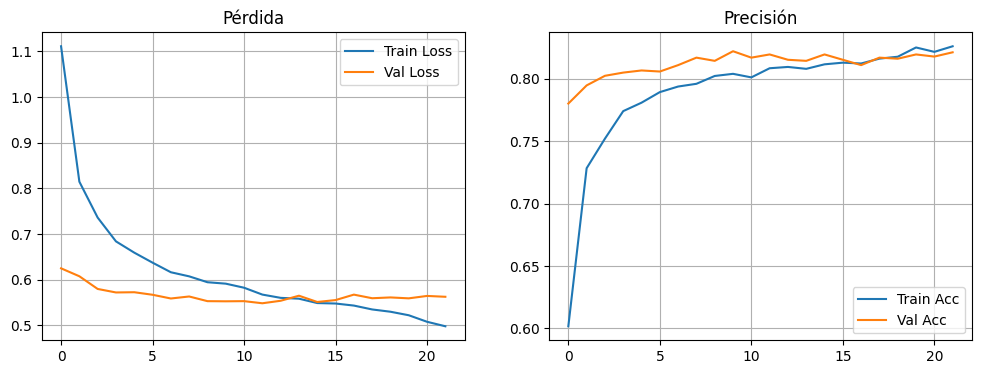

In [165]:
# graficar las curvas de pérdida y precisión
def plot_history(hist):
    plt.figure(figsize=(12, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(hist['train_loss'], label='Train Loss')
    plt.plot(hist['val_loss'], label='Val Loss')
    plt.title('Pérdida')
    plt.grid()
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(hist['train_acc'], label='Train Acc')
    plt.plot(hist['val_acc'], label='Val Acc')
    plt.title('Precisión')
    plt.grid()
    plt.legend()
    plt.show()

plot_history(model_light.history)


--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      adware       0.60      0.57      0.58       450
     banking       0.86      0.82      0.84       720
      benign       0.76      0.83      0.80      1209
    riskware       0.87      0.82      0.84      1165
         sms       0.86      0.87      0.87      1464

    accuracy                           0.81      5008
   macro avg       0.79      0.78      0.79      5008
weighted avg       0.82      0.81      0.81      5008



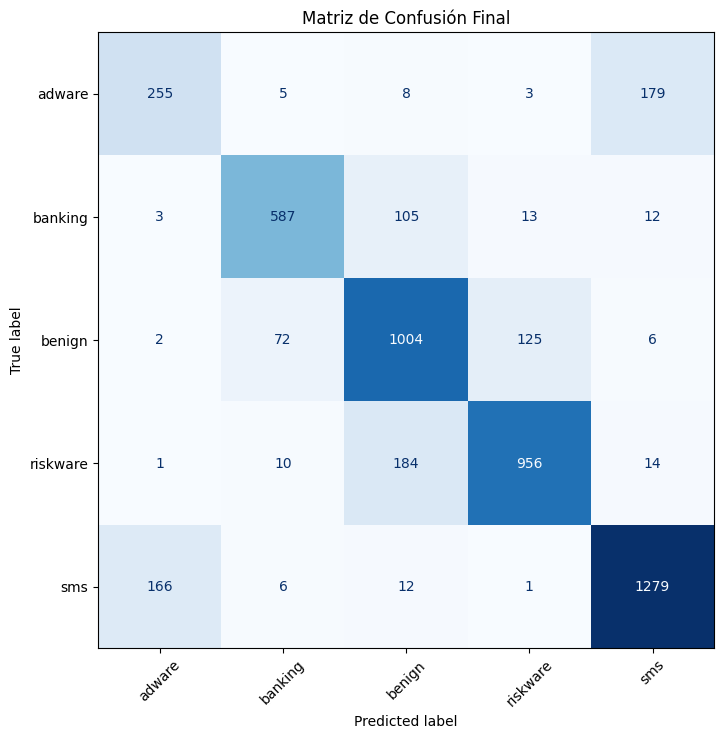

In [166]:
# evaluar en el conjunto de test
model_light.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        x, y = batch
        logits = model_light(x)
        preds = torch.max(logits, 1)[1]
        y_true.extend(y.tolist())
        y_pred.extend(preds.tolist())

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Matriz de Confusión Final')
plt.show()

## Nuevas ideas:
- Usar una recurrente para capturar la secuencia de llamadas a APIs, ya que el orden de las llamadas puede ser relevante para la clasificación.
- Usar reducción de dimensionalidad con el modelo pequeño.

# Redes secuenciales

## Preprocesamiento - entrada de secuencias

In [44]:
# recalcular la frecuencia solo con el set de entrenamiento para evitar leakage
all_labels_train = " ".join(df_train_new['Label'].tolist())
api_calls_train = all_labels_train.split()
api_calls_count_train = pd.Series(api_calls_train).value_counts()

# configuración de la secuencia
TOP_FREQUENT_APIS = 10000
MAX_SEQUENCE_LENGTH = 300 

# crear el vocabulario con las más frecuentes
# 0 para padding, 1 para OOV (desconocidas), 2+ para los tokens
vocab = {api: i+2 for i, api in enumerate(api_calls_count_train.index[:TOP_FREQUENT_APIS])}
vocab['<OOV>'] = 1 

def encode_sequence(text, vocab, max_len):
    tokens = text.split()
    # si la api no está en el top, se usa el token 1 (<OOV>)
    encoded = [vocab.get(api, 1) for api in tokens]
    
    # truncar si la secuencia es muy larga
    if len(encoded) > max_len:
        encoded = encoded[:max_len]
    
    return torch.tensor(encoded, dtype=torch.long)

# convertir los datasets a listas de tensores secuenciales
X_train_seq = [encode_sequence(s, vocab, MAX_SEQUENCE_LENGTH) for s in df_train_new['Label']]
X_val_seq = [encode_sequence(s, vocab, MAX_SEQUENCE_LENGTH) for s in df_val['Label']]
X_test_seq = [encode_sequence(s, vocab, MAX_SEQUENCE_LENGTH) for s in df_test['Label']]

# padding para que todos los tensores en el batch midan lo mismo
X_train_t = pad_sequence(X_train_seq, batch_first=True, padding_value=0)
X_val_t = pad_sequence(X_val_seq, batch_first=True, padding_value=0)
X_test_t = pad_sequence(X_test_seq, batch_first=True, padding_value=0)

# crear los dataloaders (ahora con los tensores secuenciales)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_t, y_val_t), batch_size=32, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

In [45]:
# ver un ejemplo de secuencia codificada
reduced_vocab = {k: v for k, v in vocab.items() if v < 20}  # mostrar solo las primeras 20 entradas del vocabulario
print("Vocabulario reducido (solo las primeras 20 entradas):")
for api, idx in reduced_vocab.items():
    print(f"{idx}: {api}")
print("Ejemplo de secuencia original:")
print(df_train_new.iloc[0]['Label'])
print("\nEjemplo de secuencia codificada (con padding):")
print(X_train_t[0][:50])


Vocabulario reducido (solo las primeras 20 entradas):
2: run
3: a
4: toString
5: init
6: equals
7: get
8: valueOf
9: onCreate
10: close
11: add
12: zza
13: b
14: size
15: getString
16: append
17: set
18: setContentView
19: findViewById
1: <OOV>
Ejemplo de secuencia original:
getNumber toString onCreate setContentView onClick startActivity parse initTextView initButton findViewById onCreate startProgressLoading startActivation getString initSettings areInstalledAndActivatedURLsEquals updateGUIAfterProgressLoading initGUI initTextViews setText initButtons findViewById onPostExecute setContentView doInBackground currentTimeMillis valueOf onReceive getBaseContext access6 dismiss access7 showLink startActivity onCreate onCreate setContentView setListeners initOffertView findViewById activate send hasNext iterator next init isActivated getActivatedURL getString initDataFromConfigs getTextsForCountries close next show getAppName getUrl getAllSchemes close initSchemes toString valueOf add toSt

## Modelo LSTM

In [46]:
class MalwareLSTM(L.LightningModule):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes, lr=0.0005):
        super().__init__()
        # guardar hiperparametros
        self.save_hyperparameters()
        
        # arquitectura del modelo: Embedding -> BiLSTM -> Global Pooling -> Clasificador
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # lstm bidireccional para capturar contexto en ambos sentidos
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=2,
            batch_first=True,
            dropout=0.3,
            bidirectional=True 
        )

        # arquitectura del clasificador con batch normalization
        # la entrada es hidden_dim * 4 (2 por BiLSTM y 2 por concatenar Avg y Max pooling)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim * 4, 128),
            nn.BatchNorm1d(128), # normalización después de la primera capa densa
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, num_classes)
        )

        # guardar learning rate
        self.lr = lr

        # diccionario para almacenar el promedio de métricas por época
        self.history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    def forward(self, x):
        # pasar los IDs por la capa de embedding
        x = self.embedding(x) # [batch, seq_len, embedding_dim]
        
        # la lstm retorna la salida completa y los estados
        # lstm_out tiene forma [batch, seq_len, hidden_dim * 2]
        lstm_out, _ = self.lstm(x)
        
        # global pooling para extraer las señales más importantes de toda la secuencia
        avg_pool = torch.mean(lstm_out, dim=1)
        max_pool, _ = torch.max(lstm_out, dim=1)
        
        # concatenar ambos poolings para alimentar al clasificador
        combined = torch.cat((avg_pool, max_pool), dim=1) 
        
        return self.classifier(combined)

    def training_step(self, batch, batch_idx):
        # entra el batch como tensor y etiqueta
        x, y = batch

        # forward pass
        logits = self(x)

        # calcular pérdida y precisión
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        
        # guardar los valores para el promedio por época
        self.log("train_loss", loss, on_step=False, on_epoch=True, prog_bar=True)
        self.log("train_acc", acc, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        # igual que en training pero pasando el batch de validación
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        acc = (logits.argmax(dim=1) == y).float().mean()
        
        self.log("val_loss", loss, on_epoch=True, prog_bar=True)
        self.log("val_acc", acc, on_epoch=True, prog_bar=True)
        return loss

    def on_validation_epoch_end(self):
        # guardar las métricas de la época para luego graficar el historial
        metrics = self.trainer.callback_metrics
        if "train_loss" in metrics and "val_loss" in metrics:
            self.history['train_loss'].append(metrics["train_loss"].item())
            self.history['train_acc'].append(metrics["train_acc"].item())
            self.history['val_loss'].append(metrics["val_loss"].item())
            self.history['val_acc'].append(metrics["val_acc"].item())

    def configure_optimizers(self):
        # el optimizador es Adam con weight decay para regularización
        optimizer = torch.optim.Adam(self.parameters(), lr=self.lr, weight_decay=1e-4)
        
        # scheduler para reducir el LR cuando la pérdida de validación se estanque
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, 
            mode='min', 
            factor=0.5,
            patience=5, 
        )
        
        return {
            "optimizer": optimizer,
            "lr_scheduler": {
                "scheduler": scheduler,
                "monitor": "val_loss"
            }
        }

In [47]:
# instanciar el modelo con los tamaños definidos en el preprocesamiento
model_light = MalwareLSTM(
    vocab_size=TOP_FREQUENT_APIS + 2, # +2 por padding y OOV
    embedding_dim=64, 
    hidden_dim=128, 
    num_classes=len(le.classes_),
    lr=0.001
)

# callbacks de early stopping y ckekpoint para guardar el mejor modelo basado en la pérdida de validación
early_stop = EarlyStopping(monitor="val_loss", patience=10, mode="min", verbose=True)
checkpoint = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", filename="best_model")

# trainer ajusta las épocas, callbacks, acelerador y dispositivo
trainer = L.Trainer(
    max_epochs=100,
    callbacks=[early_stop, checkpoint],
    accelerator="auto", 
    devices=1
)

# entrenar 
trainer.fit(model_light, train_loader, val_loader)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


┏━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name       ┃ Type       ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ embedding  │ Embedding  │  640 K │ train │     0 │
│ 1 │ lstm       │ LSTM       │  593 K │ train │     0 │
│ 2 │ classifier │ Sequential │ 66.6 K │ train │     0 │
└───┴────────────┴────────────┴────────┴───────┴───────┘

Trainable params: 1.3 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.3 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 8                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Metric val_loss improved. New best score: 0.745
Metric val_loss improved by 0.126 >= min_delta = 0.0. New best score: 0.619
Metric val_loss improved by 0.014 >= min_delta = 0.0. New best score: 0.605
Metric val_loss improved by 0.018 >= min_delta = 0.0. New best score: 0.587
Metric val_loss improved by 0.020 >= min_delta = 0.0. New best score: 0.567
Monitored metric val_loss did not improve in the last 10 records. Best score: 0.567. Signaling Trainer to stop.


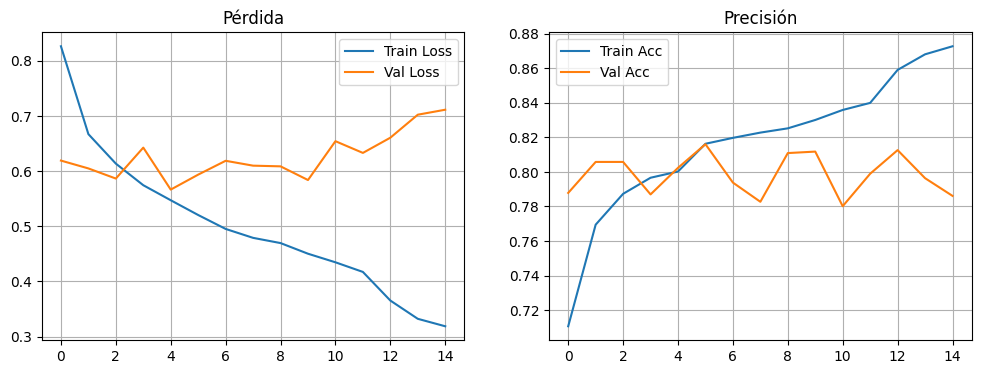

In [48]:
# graficar las curvas de pérdida y precisión
plot_history(model_light.history)


--- REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

      adware       0.59      0.48      0.53       450
     banking       0.87      0.78      0.82       720
      benign       0.75      0.73      0.74      1209
    riskware       0.76      0.86      0.81      1165
         sms       0.85      0.87      0.86      1464

    accuracy                           0.79      5008
   macro avg       0.76      0.74      0.75      5008
weighted avg       0.78      0.79      0.78      5008



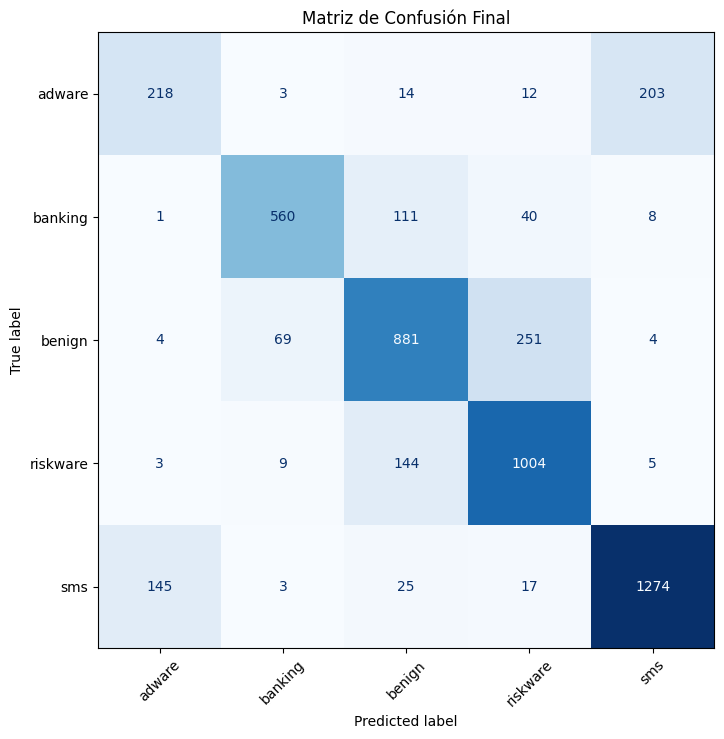

In [49]:
# evaluar en el conjunto de test
model_light.eval()
y_true, y_pred = [], []

with torch.no_grad():
    for batch in test_loader:
        x, y = batch
        logits = model_light(x)
        preds = torch.max(logits, 1)[1]
        y_true.extend(y.tolist())
        y_pred.extend(preds.tolist())

print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_true, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(cmap='Blues', ax=ax, xticks_rotation=45, colorbar=False)
plt.title('Matriz de Confusión Final')
plt.show()